In [1]:
b = 1
c = 0.156
epsilon = -0.45

gamma = -0.2
# change gamma to 0 for the second task
# gamma = 0
I = 0.0035
k_theta = 11.5
k_z = 300
m = 2.3

## Task 1: Divergence airspeed
For the task 1 we are asked to find the divergence airspeed, so no transients and no fun stuff (aka diff. eqs). A formula from the lecture is used directly here

In [2]:
import math
import numpy as np
# For RE = 700000
# https://ntrs.nasa.gov/api/citations/19880019495/downloads/19880019495.pdf page 52
cl_alpha = np.array([
    [-4.021024967148489, -0.3527673307454903],
    [-2.049934296977663, -0.17510988264080865],
    [-0.09855453350854214, -0.010857361507595073],
    [1.2417871222076213, 0.10182709783960416],
    [3.2720105124835746, 0.26989089773991676],
    [4.7109067017082795, 0.4036229804502043],
    [5.814717477003941, 0.5125364387451479],
    [7.233902759526939, 0.6232850504226645],
    [8.061760840998685, 0.6862919832243319],
])
avg_delta = np.sum(cl_alpha[:-1] - cl_alpha[1:], axis=0) / (len(cl_alpha) - 1)

dCl_dalpha = avg_delta[1] / math.radians(avg_delta[0])
dCl_dalpha

4.927151262922095

In [3]:
import fluids
rho = fluids.ATMOSPHERE_1976(0).rho
mu = fluids.ATMOSPHERE_1976(0).mu


x_EA = (1+epsilon)*c/2
x_AC = c/4

S = b*c
U_d = math.sqrt(2 * k_theta / (rho * S * dCl_dalpha * (x_EA - x_AC)))
re = fluids.Reynolds(U_d, c, rho, mu)
print(f"Reynolds number: {int(re)}")
print(f"Divergence airspeed: {U_d:.2f} m/s")

Reynolds number: 845203
Divergence airspeed: 79.14 m/s


If it is a small UAV, hitting 80m/s, which is 280kph is highly unlikely unless it is a flying engine essentially.

## Tasks two and three

$$\begin{bmatrix}\ m\ \tilde{c}\ ^2\ &\ \ m\ \tilde{c}\ ^2\ x_{theta}\ \\ m\ \tilde{c}\ ^2\ x_{theta}\ &\ I_{EA}\ \end{bmatrix}\ \begin{bmatrix}\ \frac{\ddot{z}}{\tilde{c}}\ \\ \ddot{\theta}\ \end{bmatrix}\ =\ \begin{bmatrix}\ \tilde{c}\ ^2\ k_{z}\ &\ 2\ \pi \rho \tilde{c}\ ^2\ U_{\inf}^2\ \\ 0\ &\ k_{\theta}\ \ -\ 2\ (\frac{1}{2}\ +\ \epsilon)\ \pi \rho \tilde{c}\ ^2\ U_{\inf}^2\ \ \end{bmatrix}\ \begin{bmatrix}\ \frac{z}{\tilde{c}}\ \\ \theta \end{bmatrix}\ =\ \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$

Let q be out generalized state, M is the generalized mass matrix and K is the state transition: $$M \ddot{q} + Kq = 0$$
The content of those matrices is again taken directly from the lecture. Now we express it as

$$\ddot{q} = - M^{-1}Kq$$ and let $$B = -M^{-1}K$$

To solve it with odeint let's turn the equation into a first order system by defining $x = \begin{bmatrix} \dot{q} \\ q \end{bmatrix}$ and we get

$$\dot{x} = Ax$$

where $$A = \begin{bmatrix} 0 & B \\ I & 0 \end{bmatrix}$$

And then inspect the eigenvalues of A, if any of them have a positive real part, we are divergent, and the imaginary part will give us the behavior, either oscillatory or not.

Also, that small 0.01 is a way to account for numerics, since we are doing a computational solution which might or might not be exact. 0.2 + 0.1 != 0.3 after all
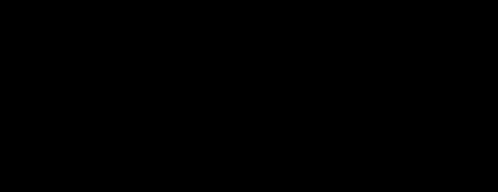
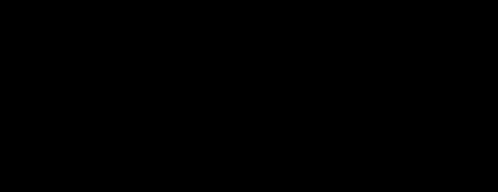
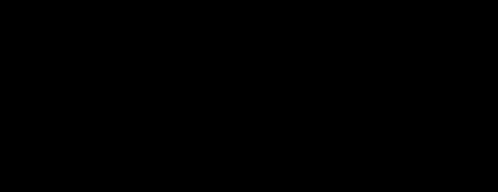
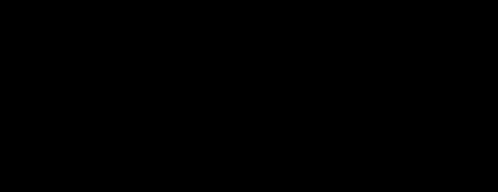

In [4]:
0.2 + 0.1 == 0.3

False

In [5]:
c_bar = c/2
U_inf = 200
x_theta = gamma - epsilon

def build_matrix(m, I, c_bar, x_theta, k_z, k_theta, rho, U_inf, epsilon):
    M = np.array([
        [m * c_bar**2, m * c_bar**2*x_theta],
        [m * c_bar**2*x_theta, I]
    ])

    K = np.array([
        [c_bar**2 * k_z, 2 * math.pi*rho*c_bar**2*U_inf**2],
        [0, k_theta - 2*(0.5+epsilon)*math.pi*rho*c_bar**2*U_inf**2]
    ])

    A = np.zeros((4,4))
    A[:2, 2:] = -np.linalg.inv(M) @ K
    A[2:, :2] = np.eye(2)
    return A


In [6]:

for U_inf in np.linspace(20, 200, 10000):
    A = build_matrix(m, I, c_bar, x_theta, k_z, k_theta, rho, U_inf, epsilon)
    eigenvalues, eigenvectors = np.linalg.eig(A)

    if any(eigenvalues.real > 0.01):
        print(f"Divergence at U_inf = {U_inf:.2f} m/s")
        break
eigenvalues

Divergence at U_inf = 24.21 m/s


array([-0.5997283+26.62640649j, -0.5997283-26.62640649j,
        0.5997283+26.62640649j,  0.5997283-26.62640649j])

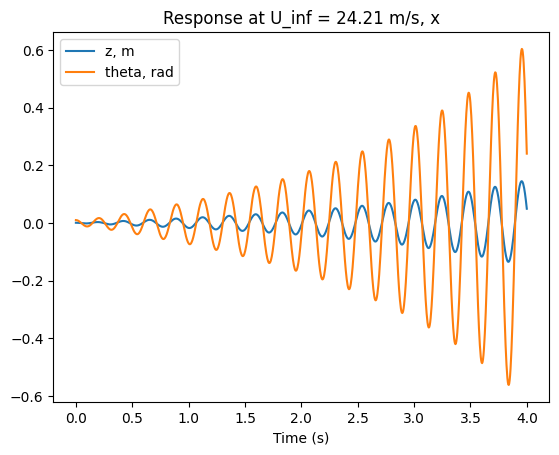

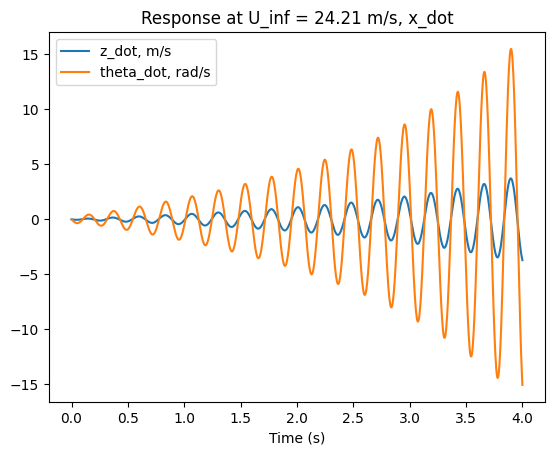

In [10]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt

A_div = build_matrix(m, I, c_bar, x_theta, k_z, k_theta, rho, U_inf, epsilon)

def model(x, t):
    return A_div @ x

x_0 = np.array([0, 0, 0.01, 0.01])
time = np.linspace(0, 4, 1000)
y = odeint(model, x_0, time)

plt.title(f'Response at U_inf = {U_inf:.2f} m/s, x')
plt.plot(time, y[:, 2]*c_bar, label='z, m')
plt.plot(time, y[:, 3], label='theta, rad')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

plt.title(f'Response at U_inf = {U_inf:.2f} m/s, x_dot')
plt.plot(time, y[:, 0]*c_bar, label='z_dot, m/s')
plt.plot(time, y[:, 1], label='theta_dot, rad/s')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

How do we get the frequency out of that? Fast Fourier Transform (FFT) is a way to get the frequency of a signal, in this case the response of the system, so let's apply that

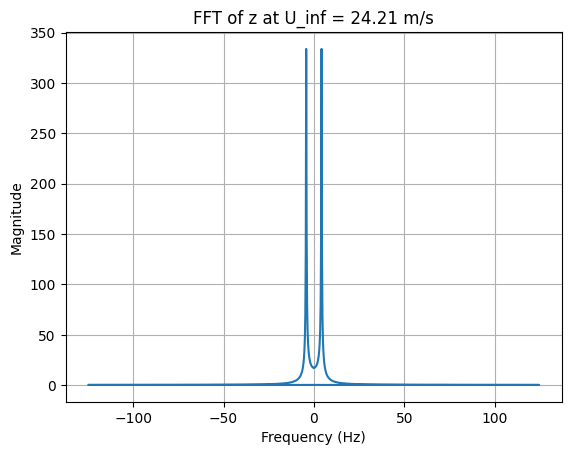

Dominant frequency: 4.25 Hz


In [8]:
from scipy.fft import fft, fftfreq
N = len(time)
dt = time[1] - time[0]
yf = fft(y[:, 2])  # FFT of z_dot
xf = fftfreq(N, dt)  # Corresponding frequencies
plt.plot(xf, np.abs(yf))
plt.title(f'FFT of z at U_inf = {U_inf:.2f} m/s')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

frequency = xf[np.argmax(np.abs(yf))]
print(f"Dominant frequency: {frequency:.2f} Hz")


Now the same should be rerun for the case where gamma = 0, just uncomment the line at the top of the file, but I will report the results here for the sake of completeness.

* Divergence at 20.72
* Dominant frequency: 5.99 Hz



## Little extra: control

What also should be interesting to see and to do is to actually design a controller for this, so that we can take this unstable system and force it to be stable. For that we will be using something called computed torque controller. Starting with this system
$$M \ddot{q} + Kq = 0$$
We add control law $u$, which is a function of state
$$M \ddot{q} + Kq + u(q) = 0$$


The idea is to design a control law such that our control essentially cancels out systems' inherent dynamics and then gives it a behavior of a desired system, for example a second order mass-spring-damper. The control law is given by
$$u = - M(\ddot{q}_d - k_d \dot{e} - k_p e) - Kq$$
Where $e = q - q_d$ is the error between the desired state and the actual state, $k_d$ is the derivative gain and $k_p$ is the proportional gain. The desired state $q_d$ can be a reference trajectory or a setpoint. If we plug that into our dynamics, the closed loop system will then be
$$\ddot{e} + k_d \dot{e} + k_p e = 0$$
Or if we turn it into the first order system, using $e = \begin{bmatrix} \dot{e} \\ e \end{bmatrix}$ we get

$$\dot{e} = A_{cl} e  $$

Where $A_{cl} = \begin{bmatrix} k_p & k_d \\ 0 & 1 \end{bmatrix}$ and we can choose $k_p$ and $k_d$ such that the we have a desired system response, which I just eyeballed for this assignment.
This is how we prove that with our control law we force the error to zero, which is desired.

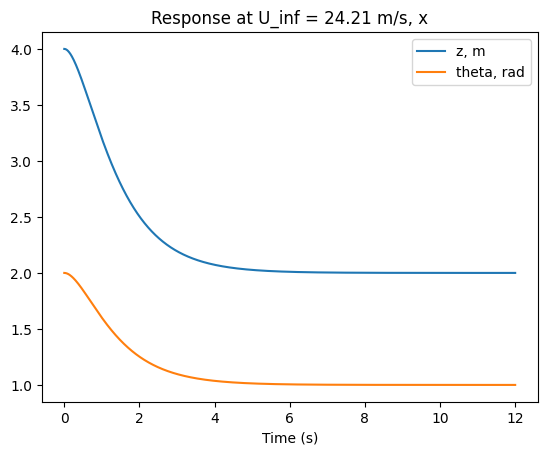

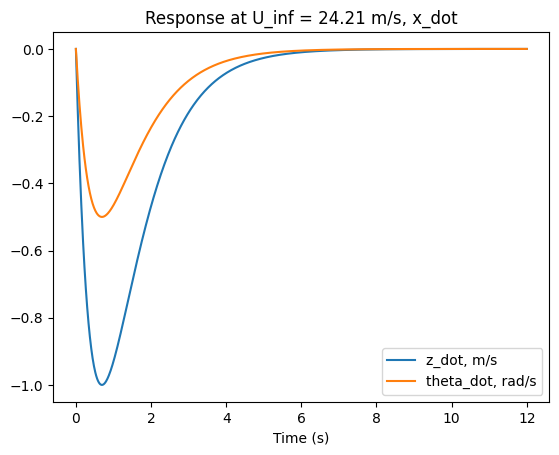

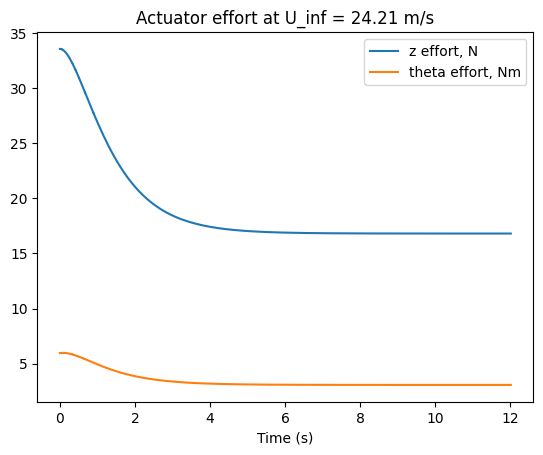

In [25]:
kd = 1
k2 = 2

x_d = np.array([0, 0, 2/c_bar, 1])  # Desired state (zdot, thetadot, z, theta)


from scipy.integrate import odeint
import matplotlib.pyplot as plt

effort_z = []
effort_theta = []
t_fn = []

def build_matrices(m, I, c_bar, x_theta, k_z, k_theta, rho, U_inf, epsilon):
    M = np.array([
        [m * c_bar**2, m * c_bar**2*x_theta],
        [m * c_bar**2*x_theta, I]
    ])

    K = np.array([
        [c_bar**2 * k_z, 2 * math.pi*rho*c_bar**2*U_inf**2],
        [0, k_theta - 2*(0.5+epsilon)*math.pi*rho*c_bar**2*U_inf**2]
    ])

    A = np.zeros((4,4))
    A[:2, 2:] = -np.linalg.inv(M) @ K
    A[2:, :2] = np.eye(2)

    B = np.zeros((4,4))
    B[:2, :2] = np.linalg.inv(M)

    return M, K, A, B

M_div, K_div, A_div, B_div = build_matrices(m, I, c_bar, x_theta, k_z, k_theta, rho, 60, epsilon)

k_d = 3
k_p = 2

def model(x, t):
    u = M_div @ (k_d*(-x[:2] + x_d[:2]) + k_p*(-x[2:] + x_d[2:])) + K_div @ x[2:]

    effort_z.append(u[0])
    effort_theta.append(u[1])
    t_fn.append(t)

    u = np.hstack([u, [0, 0]])
    return A_div @ x + B_div @ u

x_0 = np.array([0, 0, 4/c_bar, 2])
time = np.linspace(0, 12, 1000)
y = odeint(model, x_0, time)

plt.title(f'Response at U_inf = {U_inf:.2f} m/s, x')
plt.plot(time, y[:, 2]*c_bar, label='z, m')
plt.plot(time, y[:, 3], label='theta, rad')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

plt.title(f'Response at U_inf = {U_inf:.2f} m/s, x_dot')
plt.plot(time, y[:, 0]*c_bar, label='z_dot, m/s')
plt.plot(time, y[:, 1], label='theta_dot, rad/s')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

plt.title(f'Actuator effort at U_inf = {U_inf:.2f} m/s')
plt.plot(t_fn, np.array(effort_z)*c_bar, label='z effort, N')
plt.plot(t_fn, effort_theta, label='theta effort, Nm')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

This is not my best PID tune, but it does neither diverge nor overshoot crazily, so I consider it a success. The system is now stable and we can see that it converges to the desired state, which is what we wanted.

The better question is how we apply that control law (aka torque and force) to a real wing, but that is a question for another time.

In [17]:
A = np.array([
    [2, 6],
    [0, 1]
])

eigenvalues, eigenvectors = np.linalg.eig(-A)
eigenvalues

array([-2., -1.])